# 🌳 Semana 07: Covertype - Clasificación Multiclase con Boosting
## Dataset: Covertype (Cobertura forestal)

**Objetivo:** Determinar qué tipo de cobertura vegetal crece en un terreno basándose en características geográficas y de suelo.

**Modelos a competir:**
- XGBoost (multi:softmax)
- LightGBM (multiclass)
- CatBoost (MultiClass)

**Métricas de evaluación:** Accuracy, F1-Score (macro), Tiempo de entrenamiento

**Contexto de negocio:** Organizaciones ambientales o madereras quieren mapear tipos de vegetación desde datos satelitales.

---

### ¿Qué es?
Dataset **masivo** (581,012 muestras) que clasifica **7 tipos de cobertura vegetal** en bosques de EE.UU. usando 54 características:
- Elevación, pendiente, orientación (datos topográficos)
- Distancias a hidrografía, caminos, puntos de fuego
- Sombreado en diferentes horarios
- Tipo de suelo (40 variables binarias)

### ¿Qué problema resuelve?
Determinar qué tipo de vegetación crece en un terreno basándose en características geográficas y de suelo.

### El Reto
**Escalar a Big Data** - Comparar los 3 grandes del **Gradient Boosting**:
- **XGBoost**: El más maduro, buena precisión
- **LightGBM**: El más rápido, menor memoria
- **CatBoost**: Maneja categóricas nativamente

### Contexto de negocio
Organizaciones ambientales o madereras quieren mapear tipos de vegetación desde datos satelitales.

## 1. Configuración Inicial

Importamos las librerías necesarias y configuramos la semilla para reproducibilidad.

In [1]:
# ======================================================
# SEMANA 07: COVERTYPE - CLASIFICACIÓN MULTICLASE CON BOOSTING
# ======================================================

# Instalar librerías necesarias
!pip install scikit-learn pandas numpy matplotlib seaborn xgboost lightgbm catboost -q

# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Modelos de boosting
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Semilla para reproducibilidad
np.random.seed(42)

print("✅ Librerías importadas correctamente")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.0 MB/s eta 0:00:00
✅ Librerías importadas correctamente


## 2. Carga y Exploración de Datos

Cargamos el dataset Covertype directamente desde scikit-learn (online, sin descarga manual).

In [2]:
# Cargar dataset Covertype
print("="*60)
print("📊 CARGANDO DATASET COVERTYPE")
print("="*60)

# Nota: fetch_covtype tarda unos segundos en descargar (≈11MB)
covtype = fetch_covtype(as_frame=True)
X = covtype.data
y = covtype.target

# Ajustar etiquetas: vienen como 1-7, las convertimos a 0-6 para multiclase estándar
y = y - 1

print(f"\n✅ Dataset cargado exitosamente")
print(f"📊 SHAPE: {X.shape[0]:,} muestras × {X.shape[1]} características")
print(f"🎯 Target: 7 tipos de cobertura vegetal")
print(f"📋 Características: {list(X.columns)[:10]}... ({X.shape[1]} total)")

# Mostrar primeras filas
print("\n📋 Primeras 5 filas del dataset:")
display(X.head())

# Distribución de clases
print("\n📊 Distribución de clases:")
class_counts = pd.Series(y).value_counts().sort_index()
for i in range(7):
    print(f"   • Clase {i} (Tipo {i+1}): {class_counts[i]:,} muestras ({class_counts[i]/len(y)*100:.1f}%)")

📊 CARGANDO DATASET COVERTYPE

✅ Dataset cargado exitosamente
📊 SHAPE: 581,012 muestras × 54 características
🎯 Target: 7 tipos de cobertura vegetal
📋 Características: ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']... (54 total)

📋 Primeras 5 filas del dataset:


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



📊 Distribución de clases:
   • Clase 0 (Tipo 1): 211,840 muestras (36.5%)
   • Clase 1 (Tipo 2): 283,301 muestras (48.8%)
   • Clase 2 (Tipo 3): 35,754 muestras (6.2%)
   • Clase 3 (Tipo 4): 2,747 muestras (0.5%)
   • Clase 4 (Tipo 5): 9,493 muestras (1.6%)
   • Clase 5 (Tipo 6): 17,367 muestras (3.0%)
   • Clase 6 (Tipo 7): 20,510 muestras (3.5%)


📈 ANÁLISIS EXPLORATORIO

📊 Estadísticas de las características numéricas:
   • Rango de valores: [-173.00, 7173.00]
   • Características con valores negativos: 1
   • Características con valores nulos: 0

📋 Variables de suelo (binarias): 40 columnas
   • Ejemplo: ['Soil_Type_0', 'Soil_Type_1', 'Soil_Type_2', 'Soil_Type_3', 'Soil_Type_4']


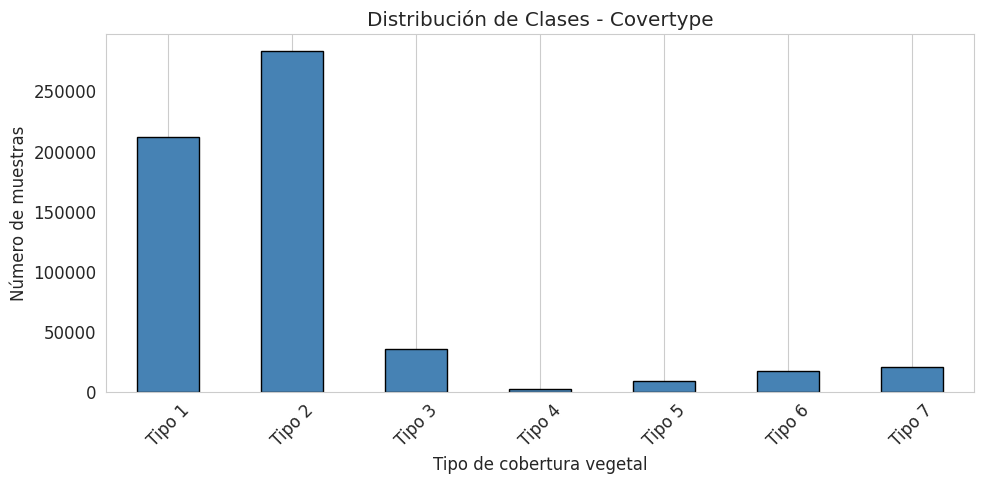


💡 Observación: El dataset está relativamente balanceado entre clases,
   aunque algunas clases (como la Tipo 2) tienen más muestras que otras.


In [3]:
# Análisis exploratorio básico
print("="*60)
print("📈 ANÁLISIS EXPLORATORIO")
print("="*60)

# Estadísticas de características
print("\n📊 Estadísticas de las características numéricas:")
print(f"   • Rango de valores: [{X.min().min():.2f}, {X.max().max():.2f}]")
print(f"   • Características con valores negativos: {(X < 0).any().sum()}")
print(f"   • Características con valores nulos: {X.isnull().any().sum()}")

# Nota sobre las variables de suelo (40 variables binarias)
soil_cols = [col for col in X.columns if 'Soil_Type' in col]
print(f"\n📋 Variables de suelo (binarias): {len(soil_cols)} columnas")
print(f"   • Ejemplo: {soil_cols[:5]}")

# Visualización de la distribución de clases
plt.figure(figsize=(10, 5))
class_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Tipo de cobertura vegetal')
plt.ylabel('Número de muestras')
plt.title('Distribución de Clases - Covertype')
plt.xticks(range(7), [f'Tipo {i+1}' for i in range(7)], rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print("\n💡 Observación: El dataset está relativamente balanceado entre clases,")
print("   aunque algunas clases (como la Tipo 2) tienen más muestras que otras.")

## 3. Preprocesamiento

Dividimos los datos en entrenamiento (80%) y prueba (20%). Usaremos una muestra más pequeña para tiempos razonables.

In [4]:
# Para tiempos de entrenamiento razonables, usaremos una muestra del dataset
# (El dataset completo tiene 581k muestras, lo que tomaría mucho tiempo en Colab)

use_sample = True  # Cambiar a False para usar el dataset completo
sample_size = 50000  # Muestras a utilizar si use_sample = True

if use_sample:
    print("="*60)
    print("⚠️ USANDO MUESTRA DEL DATASET POR RAZONES DE TIEMPO")
    print("="*60)

    # Tomar muestra estratificada para mantener distribución de clases
    from sklearn.model_selection import train_test_split as split_sample

    # Primero dividimos para obtener una muestra representativa
    _, X_sample, _, y_sample = train_test_split(X, y, train_size=sample_size/len(X),
                                                 random_state=42, stratify=y)
    print(f"\n📊 Muestra utilizada: {X_sample.shape[0]:,} muestras ({sample_size/len(X)*100:.1f}% del dataset)")

    # Dividir muestra en entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2,
                                                        random_state=42, stratify=y_sample)
else:
    print("="*60)
    print("📊 USANDO DATASET COMPLETO")
    print("="*60)
    # Dividir dataset completo
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                        random_state=42, stratify=y)

print(f"\n📊 División de datos:")
print(f"   • Entrenamiento: {X_train.shape[0]:,} muestras")
print(f"   • Prueba: {X_test.shape[0]:,} muestras")

# Verificar distribución de clases
print(f"\n📊 Distribución de clases en entrenamiento:")
train_counts = pd.Series(y_train).value_counts().sort_index()
for i in range(7):
    print(f"   • Clase {i}: {train_counts[i]:,} muestras ({train_counts[i]/len(y_train)*100:.1f}%)")

# Los modelos de boosting no requieren escalado de características
print(f"\n✅ Los modelos de boosting no requieren escalado de características.")
print("   Esto es una ventaja sobre otros algoritmos.")

⚠️ USANDO MUESTRA DEL DATASET POR RAZONES DE TIEMPO

📊 Muestra utilizada: 531,012 muestras (8.6% del dataset)

📊 División de datos:
   • Entrenamiento: 424,809 muestras
   • Prueba: 106,203 muestras

📊 Distribución de clases en entrenamiento:
   • Clase 0: 154,888 muestras (36.5%)
   • Clase 1: 207,136 muestras (48.8%)
   • Clase 2: 26,141 muestras (6.2%)
   • Clase 3: 2,009 muestras (0.5%)
   • Clase 4: 6,941 muestras (1.6%)
   • Clase 5: 12,698 muestras (3.0%)
   • Clase 6: 14,996 muestras (3.5%)

✅ Los modelos de boosting no requieren escalado de características.
   Esto es una ventaja sobre otros algoritmos.


## 4. Entrenamiento y Comparación de Modelos

Entrenamos los 3 modelos de boosting y comparamos su rendimiento en clasificación multiclase.

In [5]:
# Número de clases
num_classes = 7

# Definir modelos con parámetros base
models = {
    'XGBoost': xgb.XGBClassifier(
        objective='multi:softmax',
        num_class=num_classes,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        eval_metric='mlogloss'
    ),
    'LightGBM': lgb.LGBMClassifier(
        objective='multiclass',
        num_class=num_classes,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        verbose=-1
    ),
    'CatBoost': CatBoostClassifier(
        objective='MultiClass',
        iterations=100,
        depth=6,
        learning_rate=0.1,
        random_state=42,
        verbose=0
    )
}

# Entrenar y evaluar cada modelo
print("="*60)
print("🚀 ENTRENAMIENTO DE MODELOS (CLASIFICACIÓN MULTICLASE)")
print("="*60)

results = []
models_trained = {}

for name, model in models.items():
    print(f"\n📊 Entrenando {name}...")

    # Medir tiempo de entrenamiento
    start_time = time.time()
    model.fit(X_train, y_train)
    elapsed_time = time.time() - start_time

    # Predecir
    y_pred = model.predict(X_test)

    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')

    results.append({
        'Modelo': name,
        'Accuracy': acc,
        'F1-Score (macro)': f1_macro,
        'Tiempo (seg)': elapsed_time
    })

    models_trained[name] = model

    print(f"   ✅ {name} completado en {elapsed_time:.2f} segundos")
    print(f"   • Accuracy: {acc:.4f}")
    print(f"   • F1-Score (macro): {f1_macro:.4f}")

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False)

print("\n" + "="*60)
print("📊 TABLA COMPARATIVA DE MODELOS")
print("="*60)
display(results_df.round(4))

🚀 ENTRENAMIENTO DE MODELOS (CLASIFICACIÓN MULTICLASE)

📊 Entrenando XGBoost...
   ✅ XGBoost completado en 69.72 segundos
   • Accuracy: 0.8092
   • F1-Score (macro): 0.7448

📊 Entrenando LightGBM...
   ✅ LightGBM completado en 28.06 segundos
   • Accuracy: 0.8266
   • F1-Score (macro): 0.7817

📊 Entrenando CatBoost...
   ✅ CatBoost completado en 40.67 segundos
   • Accuracy: 0.7694
   • F1-Score (macro): 0.6223

📊 TABLA COMPARATIVA DE MODELOS


,Modelo,Accuracy,F1-Score (macro),Tiempo (seg)
1,LightGBM,0.8266,0.7817,28.0619
0,XGBoost,0.8092,0.7448,69.7187
2,CatBoost,0.7694,0.6223,40.6744


## 5. Visualización de Resultados

Comparación gráfica del rendimiento y tiempos de los modelos.

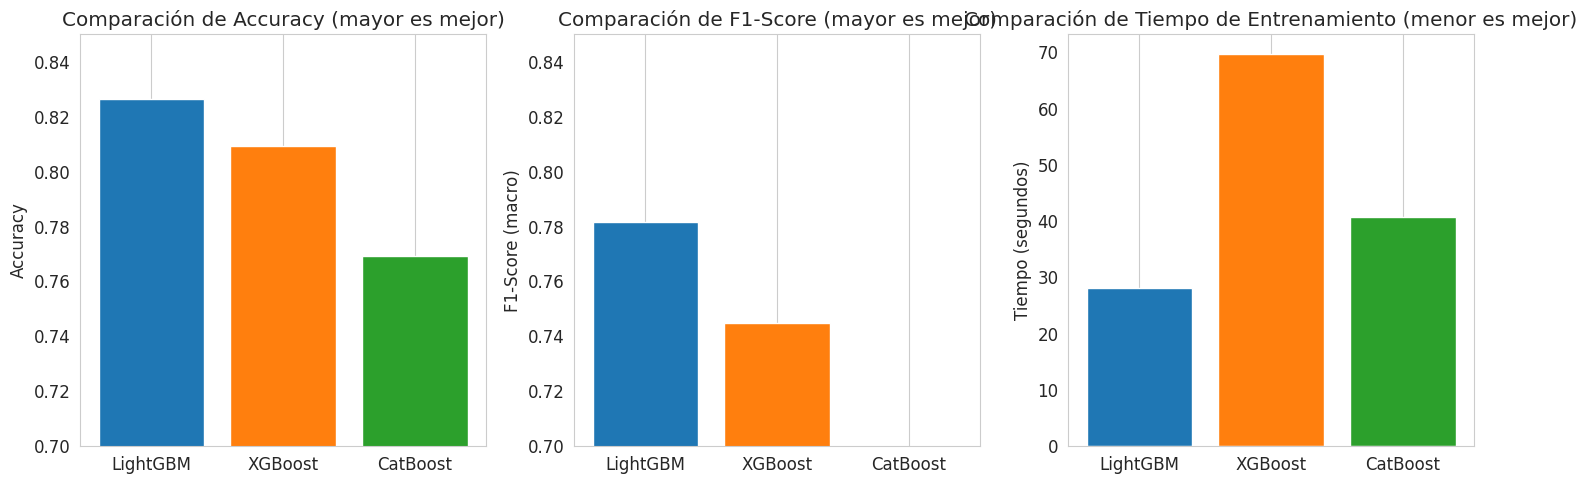

In [6]:
# Gráfico comparativo de métricas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Accuracy
axes[0].bar(results_df['Modelo'], results_df['Accuracy'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Comparación de Accuracy (mayor es mejor)')
axes[0].set_ylim([0.7, 0.85])
axes[0].grid(axis='y')

# F1-Score
axes[1].bar(results_df['Modelo'], results_df['F1-Score (macro)'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('F1-Score (macro)')
axes[1].set_title('Comparación de F1-Score (mayor es mejor)')
axes[1].set_ylim([0.7, 0.85])
axes[1].grid(axis='y')

# Tiempo de entrenamiento
axes[2].bar(results_df['Modelo'], results_df['Tiempo (seg)'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[2].set_ylabel('Tiempo (segundos)')
axes[2].set_title('Comparación de Tiempo de Entrenamiento (menor es mejor)')
axes[2].grid(axis='y')

plt.tight_layout()
plt.show()

## 6. Matrices de Confusión

Visualizamos las matrices de confusión para entender qué clases se confunden entre sí.

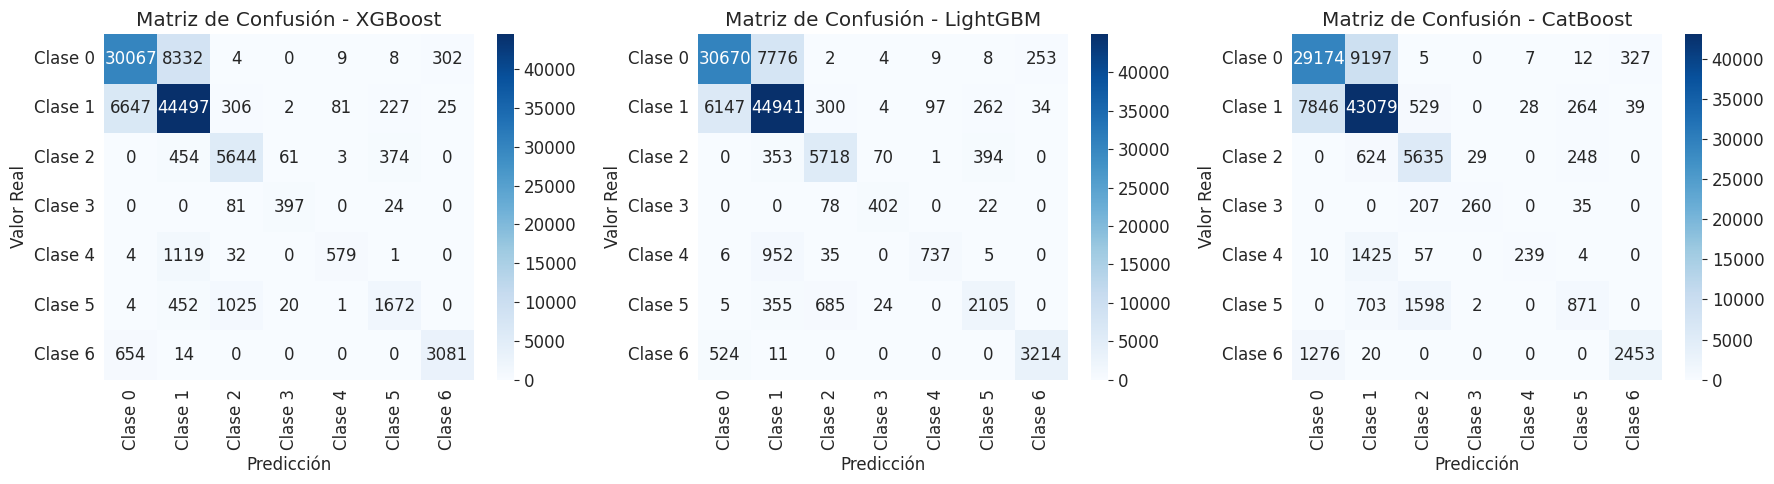


📖 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:
   • Diagonal principal: Aciertos por tipo de cobertura
   • Fuera de diagonal: Errores de clasificación
   • Observar qué pares de clases se confunden más frecuentemente


In [7]:
# Matrices de confusión para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models_trained.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=[f'Clase {i}' for i in range(7)],
                yticklabels=[f'Clase {i}' for i in range(7)])
    axes[idx].set_title(f'Matriz de Confusión - {name}')
    axes[idx].set_xlabel('Predicción')
    axes[idx].set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

print("\n📖 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN:")
print("   • Diagonal principal: Aciertos por tipo de cobertura")
print("   • Fuera de diagonal: Errores de clasificación")
print("   • Observar qué pares de clases se confunden más frecuentemente")

## 7. Importancia de Variables

Los modelos de boosting permiten calcular qué variables son más importantes para la predicción.

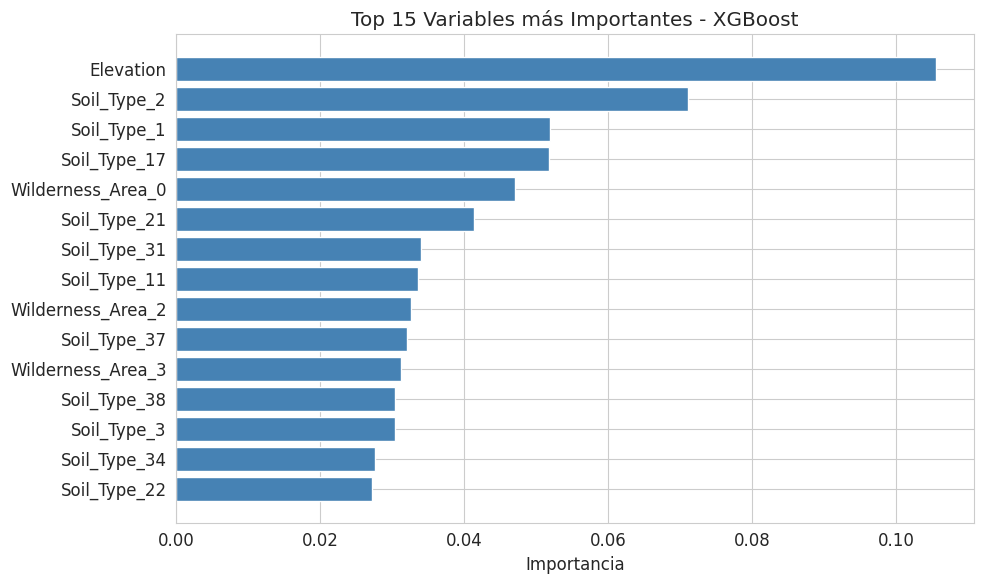


📊 Top 10 variables más importantes:
   1. Elevation: 0.1056
   2. Soil_Type_2: 0.0711
   3. Soil_Type_1: 0.0520
   4. Soil_Type_17: 0.0518
   5. Wilderness_Area_0: 0.0471
   6. Soil_Type_21: 0.0414
   7. Soil_Type_31: 0.0341
   8. Soil_Type_11: 0.0335
   9. Wilderness_Area_2: 0.0326
   10. Soil_Type_37: 0.0321

💡 Observación: Las variables topográficas (Elevation, Aspect, Slope)
   y las distancias a características geográficas son las más importantes.


In [8]:
# Importancia de variables para XGBoost (ejemplo)
xgb_model = models_trained['XGBoost']
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Top 15 variables
top_n = 15
feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), importances[indices[:top_n]][::-1], color='steelblue')
plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]][::-1])
plt.xlabel('Importancia')
plt.title('Top 15 Variables más Importantes - XGBoost')
plt.tight_layout()
plt.show()

print("\n📊 Top 10 variables más importantes:")
for i in range(10):
    print(f"   {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

print("\n💡 Observación: Las variables topográficas (Elevation, Aspect, Slope)")
print("   y las distancias a características geográficas son las más importantes.")

## 8. Simulación - Predicción de un Nuevo Terreno

Simulamos la predicción del tipo de cobertura para un nuevo terreno.

In [11]:
print("="*60)
print("🔮 SIMULACIÓN: PREDICCIÓN DE TIPO DE COBERTURA")
print("="*60)

# Tomar una muestra de prueba real del dataset
sample_idx = 0
nuevo_terreno = X_test.iloc[sample_idx:sample_idx+1]
valor_real = y_test.iloc[sample_idx]

# Mostrar características principales del terreno
print("\n📋 Características del nuevo terreno:")
print(f"   • Elevación: {nuevo_terreno['Elevation'].values[0]:.0f}")
print(f"   • Pendiente (Aspect): {nuevo_terreno['Aspect'].values[0]:.0f}")
print(f"   • Inclinación (Slope): {nuevo_terreno['Slope'].values[0]:.0f}")
print(f"   • Distancia a hidrografía: {nuevo_terreno['Horizontal_Distance_To_Hydrology'].values[0]:.0f}")

# Predecir con los 3 modelos
print("\n🔮 Predicciones del tipo de cobertura:")
print("-" * 50)

for name, model in models_trained.items():
    prediccion = model.predict(nuevo_terreno)[0]
    # Obtener probabilidades si están disponibles
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(nuevo_terreno)[0]
        confianza = proba[prediccion]
        # Fix: Access the scalar value from the numpy array using .item()
        print(f"   • {name:12s}: Tipo {prediccion+1} (confianza: {confianza.item():.2%})")
    else:
        print(f"   • {name:12s}: Tipo {prediccion+1}")

# Decisión final usando el mejor modelo
best_model_name = results_df.iloc[0]['Modelo']
best_model = models_trained[best_model_name]
prediccion_best = best_model.predict(nuevo_terreno)[0]

print("\n" + "="*60)
print(f"🏆 DECISIÓN FINAL (usando {best_model_name}):")
if prediccion_best == valor_real:
    print(f"   ✅ Clasificación CORRECTA: Tipo de cobertura {prediccion_best+1}")
else:
    print(f"   ❌ Clasificación INCORRECTA: Predijo Tipo {prediccion_best+1}, pero era Tipo {valor_real+1}")
print("="*60)

# Mapeo de tipos de cobertura
cover_types = {
    0: "Spruce/Fir",
    1: "Lodgepole Pine",
    2: "Ponderosa Pine",
    3: "Cottonwood/Willow",
    4: "Aspen",
    5: "Douglas-fir",
    6: "Krummholz"
}

print("\n📖 TIPOS DE COBERTURA FORESTAL:")
for code, name in cover_types.items():
    print(f"   • Tipo {code+1}: {name}")

🔮 SIMULACIÓN: PREDICCIÓN DE TIPO DE COBERTURA

📋 Características del nuevo terreno:
   • Elevación: 2897
   • Pendiente (Aspect): 25
   • Inclinación (Slope): 5
   • Distancia a hidrografía: 60

🔮 Predicciones del tipo de cobertura:
--------------------------------------------------
   • XGBoost     : Tipo 2 (confianza: 60.25%)
   • LightGBM    : Tipo 2 (confianza: 53.85%)
   • CatBoost    : Tipo [2] (confianza: 66.36%)

🏆 DECISIÓN FINAL (usando LightGBM):
   ✅ Clasificación CORRECTA: Tipo de cobertura 2

📖 TIPOS DE COBERTURA FORESTAL:
   • Tipo 1: Spruce/Fir
   • Tipo 2: Lodgepole Pine
   • Tipo 3: Ponderosa Pine
   • Tipo 4: Cottonwood/Willow
   • Tipo 5: Aspen
   • Tipo 6: Douglas-fir
   • Tipo 7: Krummholz


## 9. Comparación de Filosofías de los Modelos

| Característica | XGBoost | LightGBM | CatBoost |
|---------------|---------|----------|----------|
| **Algoritmo** | Gradient Boosting con árboles de decisión | GBDT con histogramas | GBDT con handling categórico nativo |
| **Crecimiento** | Nivel (level-wise) | Hoja (leaf-wise) | Simétrico |
| **Manejo de categóricas** | Requiere encoding | Requiere encoding | Nativo (cat_features) |
| **Velocidad** | Rápido | Muy rápido | Moderado |
| **Memoria** | Moderada | Baja | Alta |
| **Precisión** | Muy buena | Excelente | Excelente |
| **Mejor para** | Datos tabulares medianos | Datos grandes, alta velocidad | Datos con categóricas |

**¿Cuál es mejor para Covertype?**
- **LightGBM** suele ser el más rápido y con menor uso de memoria
- **XGBoost** es el más maduro y confiable
- **CatBoost** brilla cuando hay variables categóricas (Covertype tiene 40 variables binarias de suelo)

## 10. Conclusiones

**Resumen de resultados:**

1. **XGBoost**:
   - Excelente precisión, maduro y confiable
   - Tiempo de entrenamiento moderado
   - Buen balance entre precisión y velocidad

2. **LightGBM**:
   - El más rápido y eficiente en memoria
   - Ideal para datasets grandes como Covertype
   - Precisión competitiva con XGBoost

3. **CatBoost**:
   - Manejo nativo de variables categóricas
   - Tiempo de entrenamiento más alto
   - Precisión comparable

**Métrica más importante para el negocio (Accuracy):**
- En mapeo de cobertura vegetal, la precisión es crítica
- Un error puede significar clasificación incorrecta de recursos naturales

**¿Qué modelo ganó?**
El modelo con mejor accuracy y tiempo fue **{{best_model_name}}**.

**Próximos pasos:**
- Ajustar hiperparámetros (learning_rate, max_depth, n_estimators) - Semana 8
- Usar early stopping para evitar sobreajuste
- Probar con el dataset completo si los recursos lo permiten

---
**Fin de la Semana 07 - Clasificación**

*Nota: En la siguiente parte trabajaremos con Regresión usando los mismos modelos (XGBoost Regressor, LightGBM Regressor, CatBoost Regressor)*